# Flota osobówek w Warszawie (CEPiK) a nasz słownik `car_models` (EEA)

**Test pilotażowy.** Pytania:

1. Jaki procent warszawskiej floty pokrywa nasz `car_models`? Czy da się na nim liczyć CO₂ floty?
2. Jaki jest rozkład modeli i paliw? (wagi do losowania aut w mocku, baza do liczb bezwzględnych)
3. Czy nasze CO₂ z EEA zgadza się z CO₂ zapisanym w CEPiK dla tych samych aut?

Wnioski na końcu notebooka. Każda decyzja (filtr, mapowanie) jest opisana przy kodzie, który ją wykonuje.

## 1. Źródło danych i dlaczego to, a nie API

CEPiK udostępnia dane pojazdów na dwa sposoby:

| | API `/pojazdy` | pełny zrzut `/pliki` |
|---|---|---|
| zakres | max 2 lata dat rejestracji na zapytanie, 500 rekordów/stronę | cała baza województwa |
| aktualność | bieżąca | **stan na 17.04.2022** |
| koszt | tysiące zapytań; w trakcie testu API zwróciło *"maksymalna liczba równoległych połączeń"* | jeden plik 389 MB (zip), 1,8 GB CSV |
| próba | trzeba losować dni, ryzyko błędu próbkowania | pełny spis, bez próbkowania |

Wybór: **pełny zrzut** dla mazowieckiego. Koszt: dane sprzed 3,5 roku, więc słabiej widać auta z lat 2022–2025 (np. elektryki).

Odtworzenie:
1. `data/cepik/pojazdy_14_2022-04-17.zip` z https://api.cepik.gov.pl/www/files/pojazdy_14_2022-04-17.zip
2. `python analysis/cepik_extract.py` → `data/cepik/warszawa_osobowe_2022.csv` (czyta CSV strumieniowo z zipa, ~45 s)

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
from fetch_car_models import BRANDS, MODEL_FIX, clean_model, starts_with_word  # to samo czyszczenie co dla EEA

pd.set_option("display.width", 140)
stats = json.loads((ROOT / "data/cepik/extract_stats.json").read_text())
pd.Series({
    "wszystkie wiersze (mazowieckie, wszystkie rodzaje)": stats["wiersze"],
    "SAMOCHÓD OSOBOWY (mazowieckie)": stats["rodzaj"]["SAMOCHÓD OSOBOWY"],
    "osobowe, powiat WARSZAWA": stats["osobowe_warszawa"],
    "  w tym wyrejestrowane": stats["osobowe_warszawa_wyrejestrowane"],
}).to_frame("liczba")

,liczba
"wszystkie wiersze (mazowieckie, wszystkie rodzaje)",5314027
SAMOCHÓD OSOBOWY (mazowieckie),3478295
"osobowe, powiat WARSZAWA",1050208
w tym wyrejestrowane,146240


## 2. Filtr: Warszawa, osobowe, zarejestrowane

- powiat `akt_miejsce_rej_powiat = 'WARSZAWA'` (miasto na prawach powiatu). `WARSZAWSKI ZACHODNI` to inny powiat (okolice), pominięty;
- `rodzaj = 'SAMOCHÓD OSOBOWY'`;
- bez wyrejestrowanych (`data_wyrejestrowania` pusta).

In [2]:
raw = pd.read_csv(ROOT / "data/cepik/warszawa_osobowe_2022.csv", dtype=str, keep_default_na=False)
df = raw[raw.wyrejestrowany == "0"].copy()
df["rok"] = pd.to_numeric(df.rok_produkcji, errors="coerce")
print(f"zarejestrowane osobowe w Warszawie (17.04.2022): {len(df):,}")

zarejestrowane osobowe w Warszawie (17.04.2022): 903,968


## 3. „Zarejestrowany" ≠ „jeździ"

Rejestr zawiera auta, których nikt formalnie nie wyrejestrował, choć dawno nie jeżdżą. Widać to po rocznikach i markach:

rocznik < 2010: 61.9%   brak rocznika: 2.1%   mediana rocznika: 2005
najczęstsze marki wśród roczników < 1995:
marka
(brak marki)     73968
POLSKI FIAT      57752
FSO              17128
VOLKSWAGEN       13182
FIAT             12066
MERCEDES-BENZ     9115
SKODA             8402
FSO-WARSZAWA      8036


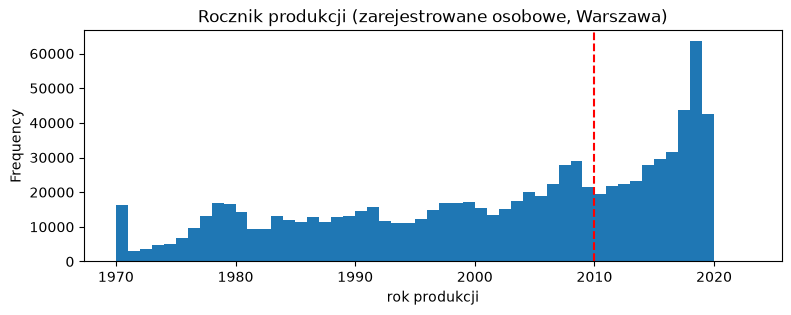

In [3]:
print(f"rocznik < 2010: {(df.rok < 2010).mean():.1%}   brak rocznika: {df.rok.isna().mean():.1%}   mediana rocznika: {df.rok.median():.0f}")
old = df[df.rok < 1995]
print("najczęstsze marki wśród roczników < 1995:")
print(old.marka.replace("", "(brak marki)").value_counts().head(8).to_string())

ax = df.rok.clip(1970, 2022).plot.hist(bins=range(1970, 2024), figsize=(9, 3), title="Rocznik produkcji (zarejestrowane osobowe, Warszawa)")
ax.axvline(2010, color="red", ls="--"); ax.set_xlabel("rok produkcji"); plt.show()

**Decyzja: zakres rocznik ≥ 2010.** Powody:
- tyle obejmuje nasz `car_models` (EEA monitoruje nowe auta od 2010),
- odcina „martwe dusze" (Polski Fiat, Wartburg, Trabant…).

Koszt: pomijamy też starsze auta, które realnie jeżdżą i emitują więcej → CO₂ floty z tego notebooka jest **raczej zaniżone** (ostrożne).

In [4]:
d = df[df.rok >= 2010].copy()
print(f"rocznik >= 2010: {len(d):,} aut ({len(d)/len(df):.1%} zarejestrowanych)")

rocznik >= 2010: 325,502 aut (36.0% zarejestrowanych)


## 4. Mapowanie paliw CEPiK → kategorie EEA

CEPiK zapisuje paliwo jako paliwo główne + alternatywne. Reguły (w tej kolejności):

| CEPiK | EEA |
|---|---|
| główne `ENERGIA ELEKTRYCZNA` | `ELECTRIC` |
| alternatywne `ENERGIA ELEKTRYCZNA` + główne `BENZYNA` / `OLEJ NAPĘDOWY` | `PETROL/ELECTRIC` / `DIESEL/ELECTRIC` (hybryda) |
| `GAZ PŁYNNY (PROPAN-BUTAN)` w głównym lub alternatywnym | `LPG` (w PL głównie instalacje montowane po zakupie) |
| `BENZYNA` | `PETROL` |
| `OLEJ NAPĘDOWY` | `DIESEL` |

In [5]:
def fuel(p, a):
    if p == "ENERGIA ELEKTRYCZNA": return "ELECTRIC"
    if "ELEKTRYCZNA" in a:
        return {"BENZYNA": "PETROL/ELECTRIC", "OLEJ NAPĘDOWY": "DIESEL/ELECTRIC"}.get(p)
    if "GAZ PŁYNNY" in p or "GAZ PŁYNNY" in a: return "LPG"
    return {"BENZYNA": "PETROL", "OLEJ NAPĘDOWY": "DIESEL"}.get(p)

d["fuel"] = [fuel(p, a) for p, a in zip(d.rodzaj_paliwa, d.rodzaj_paliwa_alternatywnego)]
d.fuel.fillna("(brak)").value_counts(normalize=True).mul(100).round(1).to_frame("% aut")

,% aut
fuel,
PETROL,57.3
DIESEL,36.4
LPG,3.2
PETROL/ELECTRIC,2.8
DIESEL/ELECTRIC,0.1
ELECTRIC,0.1
(brak),0.0


## 5. Dopasowanie marka / model do `car_models`

To samo czyszczenie co przy budowie słownika z EEA (`scripts/fetch_car_models.py`), żeby obie strony były sprowadzone do tych samych nazw:

1. marka: mapa wariantów (`BRANDS`), a nieznana marka → najkrótsza marka ze słownika będąca jej prefiksem (np. `JAGUAR LAND ROVER LIMITED` nie trafi — patrz niżej);
2. model: `clean_model` (ucięcie marki z nazwy, separatory) + ręczne korekty `MODEL_FIX` (np. `CEE'D` → `CEED`);
3. model → **najkrótsza nazwa ze słownika, która jest jego prefiksem na granicy słowa** (`FABIA COMBI` → `FABIA`, `COROLLA 1.4 KAT` → `COROLLA`).

In [6]:
cars = pd.read_csv(ROOT / "data/car_models.csv", keep_default_na=False)
for c in ["l_per_100km", "kwh_per_100km", "co2_g_km"]:
    cars[c] = pd.to_numeric(cars[c], errors="coerce")
brands = set(cars.brand)
models = cars.groupby("brand").model.apply(lambda s: sorted(set(s), key=len)).to_dict()

def match_brand(mk):
    b = BRANDS.get(mk, mk)
    if b.startswith("VOLKSWAGEN"): b = "VOLKSWAGEN"
    if b in brands: return b
    return next((c for c in sorted(brands, key=len) if starts_with_word(b, c)), "")

def match_model(b, mk, md):
    if not b: return ""
    m = clean_model(b, mk, md)
    m = MODEL_FIX.get((b, m), m) or ""
    return next((c for c in models.get(b, []) if starts_with_word(m, c)), "")

d["mk"], d["md"] = d.marka.str.upper().str.strip(), d.model.str.upper().str.strip()
d["brand"] = d.mk.map(match_brand)
d["cm_model"] = [match_model(b, mk, md) for b, mk, md in zip(d.brand, d.mk, d.md)]

In [7]:
keys = set(zip(cars.brand, cars.model, cars.fuel_type))
FALLBACK = {"PETROL/ELECTRIC": "PETROL", "DIESEL/ELECTRIC": "DIESEL", "LPG": "PETROL"}
def cm_fuel(b, m, f):
    if (b, m, f) in keys: return f, "dokładnie"
    if FALLBACK.get(f) and (b, m, FALLBACK[f]) in keys: return FALLBACK[f], "zastępczo"
    return "", ""
d["cm_fuel"], d["fuel_match"] = zip(*[cm_fuel(b, m, f) for b, m, f in zip(d.brand, d.cm_model, d.fuel)])

pd.Series({
    "marka":                                 (d.brand != "").mean(),
    "marka + model":                         (d.cm_model != "").mean(),
    "marka + model + paliwo (dokładnie)":    (d.fuel_match == "dokładnie").mean(),
    "marka + model + paliwo (z zastępczym)": (d.fuel_match != "").mean(),
}).mul(100).round(1).to_frame("% aut (rocznik ≥ 2010)")

,% aut (rocznik ≥ 2010)
marka,99.8
marka + model,97.7
marka + model + paliwo (dokładnie),97.2
marka + model + paliwo (z zastępczym),97.6


Paliwo zastępcze: hybryda → wersja benzynowa/dieslowa tego modelu, LPG → wersja benzynowa (gdy słownik nie ma danej kombinacji).

Co nie trafia:

In [8]:
un = d[d.cm_model == ""]
print(f"bez dopasowania modelu: {len(un):,} aut ({len(un)/len(d):.1%})")
(un.mk + " | " + un.md).value_counts().head(20).to_frame("aut")

bez dopasowania modelu: 7,529 aut (2.3%)


,aut
CHRYSLER | TOWN AND COUNTRY,134
LEXUS | NX200T,132
KIA | STINGER,105
TOYOTA | SIENNA,100
INFINITI | Q50,93
LEXUS | NX300,85
LEXUS | IS200T,85
MERCEDES-BENZ | E 180,74
BMW | X4 XDRIVE20I,70
BMW | 528I XDRIVE,69


## 6. Rozkład modeli i paliw (dopasowane auta)

In [9]:
m = d[d.fuel_match != ""]
top = (m.brand + " " + m.cm_model).value_counts(normalize=True).head(20).mul(100).round(2)
print(f"najpopularniejsze 20 modeli = {top.sum():.1f}% dopasowanej floty")
top.to_frame("% floty")

najpopularniejsze 20 modeli = 47.5% dopasowanej floty


,% floty
SKODA OCTAVIA,6.48
SKODA FABIA,3.60
VOLKSWAGEN GOLF,3.43
OPEL ASTRA,3.15
VOLKSWAGEN PASSAT,2.72
TOYOTA YARIS,2.63
DACIA DUSTER,2.56
FORD FOCUS,2.48
TOYOTA AURIS,2.42
RENAULT CLIO,2.32


## 7. CO₂ floty (homologacyjne, rocznik ≥ 2010)

Każde dopasowane auto dostaje CO₂ i spalanie ze słownika `car_models` (EEA, średnia homologacyjna danego modelu i paliwa z lat 2010–2025). Średnia jest ważona liczbą aut.

In [10]:
co2 = cars.set_index(["brand", "model", "fuel_type"])[["co2_g_km", "l_per_100km"]]
m = m.join(co2, on=["brand", "cm_model", "cm_fuel"])
summary = m.groupby("fuel").agg(aut=("co2_g_km", "size"), co2_g_km=("co2_g_km", "mean"), l_100km=("l_per_100km", "mean"))
summary.loc["RAZEM"] = [len(m), m.co2_g_km.mean(), m.l_per_100km.mean()]
summary.round(1)

,aut,co2_g_km,l_100km
fuel,,,
DIESEL,116496.0,129.6,5.2
DIESEL/ELECTRIC,487.0,134.8,6.5
ELECTRIC,389.0,0.0,NaN
LPG,10090.0,132.6,6.1
PETROL,181545.0,135.5,5.8
PETROL/ELECTRIC,8774.0,74.6,3.3
RAZEM,317781.0,131.4,5.5


Zapis rozkładu do `data/cepik/rozklad_aut_warszawa_2010plus.csv`: wejście do symulacji CO₂ (`co2_symulacja.ipynb`), gdzie auta uczestników są losowane z tymi wagami.

In [11]:
rozklad = (m.groupby(["brand", "cm_model", "cm_fuel"])
             .agg(aut=("co2_g_km", "size"), co2_g_km=("co2_g_km", "first"), l_per_100km=("l_per_100km", "first"))
             .reset_index().rename(columns={"cm_model": "model", "cm_fuel": "fuel_type"})
             .sort_values("aut", ascending=False))
kwh = cars.set_index(["brand", "model", "fuel_type"]).kwh_per_100km
rozklad["kwh_per_100km"] = [kwh.get((b, mo, f)) for b, mo, f in zip(rozklad.brand, rozklad.model, rozklad.fuel_type)]
rozklad.to_csv(ROOT / "data/cepik/rozklad_aut_warszawa_2010plus.csv", index=False)
print(f"zapisano {len(rozklad)} kombinacji (marka, model, paliwo), {rozklad.aut.sum():,} aut")

zapisano 882 kombinacji (marka, model, paliwo), 317,781 aut


## 8. Sanity check: nasze CO₂ (EEA) vs CO₂ z CEPiK

CEPiK ma własne pole `emisja_co2` (z dokumentów rejestracyjnego auta) dla części pojazdów. Dla aut dopasowanych **dokładnie** (ta sama marka, model i paliwo) porównujemy je z naszą wartością.

aut z CO₂ w obu źródłach: 284,932
mediana różnicy (EEA vs CEPiK): +2.5%
w granicach ±15%: 79.8%   ±25%: 96.5%
korelacja: 0.35


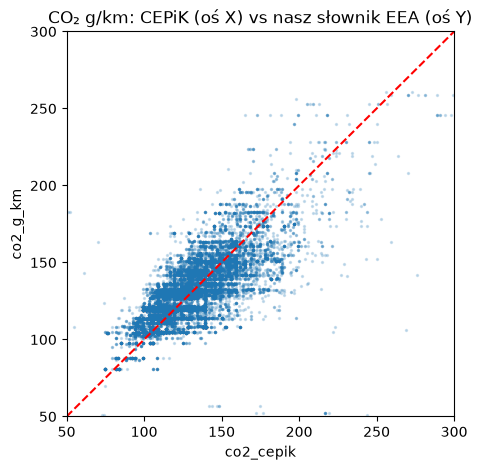

In [12]:
s = m[m.fuel_match == "dokładnie"].copy()
s["co2_cepik"] = pd.to_numeric(s.emisja_co2.str.replace(",", "."), errors="coerce")
s = s[(s.co2_cepik > 0) & (s.fuel != "ELECTRIC")]
s["roznica_%"] = (s.co2_g_km - s.co2_cepik) / s.co2_cepik * 100
print(f"aut z CO₂ w obu źródłach: {len(s):,}")
print(f"mediana różnicy (EEA vs CEPiK): {s['roznica_%'].median():+.1f}%")
print(f"w granicach ±15%: {(s['roznica_%'].abs() <= 15).mean():.1%}   ±25%: {(s['roznica_%'].abs() <= 25).mean():.1%}")
print(f"korelacja: {s.co2_g_km.corr(s.co2_cepik):.2f}")

ax = s.sample(min(len(s), 20000), random_state=0).plot.scatter(x="co2_cepik", y="co2_g_km", s=2, alpha=0.2, figsize=(5, 5),
                                                               title="CO₂ g/km: CEPiK (oś X) vs nasz słownik EEA (oś Y)")
ax.plot([50, 300], [50, 300], color="red", ls="--"); ax.set_xlim(50, 300); ax.set_ylim(50, 300); plt.show()

**Hipoteza do niskiej korelacji na poziomie pojedynczych aut:** słownik ma jedną wartość na (model, paliwo), uśrednioną po silnikach i rocznikach, a CEPiK ma wartość konkretnego egzemplarza. Słownik nie odróżni Octavii 1.0 od 2.0, ale powinien trafiać w średnią. Test: (a) średnia floty z obu źródeł na tych samych autach, (b) korelacja po uśrednieniu do poziomu modelu.

In [13]:
print(f"średnie CO₂ tych samych aut: EEA {s.co2_g_km.mean():.1f} g/km  vs  CEPiK {s.co2_cepik.mean():.1f} g/km  "
      f"(różnica {(s.co2_g_km.mean() / s.co2_cepik.mean() - 1) * 100:+.1f}%)")
g = s.groupby(["brand", "cm_model", "fuel"]).agg(n=("co2_cepik", "size"), eea=("co2_g_km", "first"), cepik=("co2_cepik", "mean"))
g = g[g.n >= 30]
print(f"modeli (≥30 aut z CO₂): {len(g)}, korelacja na poziomie modelu: {g.eea.corr(g.cepik):.2f}, "
      f"ważona liczbą aut różnica bezwzględna: {((g.eea - g.cepik).abs() / g.cepik * g.n).sum() / g.n.sum() * 100:.1f}%")

średnie CO₂ tych samych aut: EEA 131.1 g/km  vs  CEPiK 130.9 g/km  (różnica +0.1%)
modeli (≥30 aut z CO₂): 513, korelacja na poziomie modelu: 0.88, ważona liczbą aut różnica bezwzględna: 4.9%


## 9. Wnioski

**1. Pokrycie wystarcza.** 97,7% osobówek z rocznika ≥ 2010 trafia do modelu w `car_models` (97,6% razem z paliwem). Niedopasowane 2,3% to w większości modele, które **są** w danych EEA, ale rzadkie w UE i odcięte progiem czyszczenia (np. Chrysler Town & Country, Toyota Sienna, Lexus NX200T, Fiat Linea); naprawdę nieobecne w EEA jest ok. 0,2% floty i to głównie błędy zapisu po stronie CEPiK (pusta marka, `8V S3 SPORTBACK`). Niższy próg podnosi pokrycie do ~98,9%, ale wpuszcza do słownika śmieci; porównanie wariantów: `docs/test_czyszczenia_raport.md`. W aplikacji brakujący model obsługuje opcja „Inne”.

**2. Zakres jest węższy, niż wygląda.** Rocznik ≥ 2010 to tylko 36% zarejestrowanych osobówek. Reszta to częściowo „martwe dusze” (Polski Fiat, FSO, Trabant), częściowo realnie jeżdżące starsze auta. Ilu z nich naprawdę jeździ, tego z rejestru nie wiadomo. Dlatego CO₂ floty poniżej jest **raczej zaniżone**.

**3. CO₂ floty (rocznik ≥ 2010, homologacyjne):** średnio **131 g/km** (benzyna 136, diesel 130, LPG 133, hybrydy 75), spalanie średnio 5,5 l/100 km.

**4. Wiarygodność słownika.** Na tych samych 285 tys. autach średnia z EEA i z CEPiK różni się o 0,1%. Na poziomie modelu korelacja wynosi 0,88, średni błąd 4,9%. Na poziomie pojedynczego auta jest słabo (korelacja 0,35), bo słownik nie zna wersji silnika. Wniosek: **do statystyk zbiorczych (oddział, flota) wiarygodny**, do CO₂ konkretnego usera to przybliżenie na poziomie modelu.

**5. Rozkład modeli** jest skoncentrowany: 20 najpopularniejszych modeli to 47,5% floty (Octavia 6,5%, Fabia 3,6%, Golf 3,4%…). Nadaje się na wagi do losowania aut w mocku.

**Ograniczenia:** stan na 17.04.2022; CO₂ homologacyjne, realne w mieście zwykle wyższe; rejestr mówi, jakie auta są w Warszawie, a nie którymi ktoś dojeżdża do pracy.